# Uncertainty Quantification in Regression


This notebook introduces uncertainty quantification in deep learning for regression problems. <br>
The notebook is part of the HAICON 2026 Uncertainty Quantification Workshop.

## Learning Goals
- Understand **aleatoric** (data noise) vs **epistemic** (model/knowledge) uncertainty in regression tasks
- Train models that model the aleatoric uncertainty
- Compare multiple UQ approaches for aleatoric and epistemic uncertainty quantification

## Methods Covered
The notebook introduces and covers the following approaches.

| Method | Aleatoric | Epistemic | Distribution assumption |
|--------|:---------:|:---------:|------------------------|
| Plain MSE MLP | ❌ | ❌ | none |
| Gaussian NLL | ✅ | ❌ | Gaussian |
| Quantile Regression | ✅ | ❌ | **none** — distribution-free |
| Deep Ensembles | ✅ | ✅ | Gaussian (approx.) |
| SNGP | ✅ | ✅ | GP |

---


### Run Setup

In [126]:
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
print(f"Seed set to {SEED}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Seed set to 42
Device: cuda


---
## 1  The Toy Dataset

We use the following function and noise model for the data generation:

$$\mu(x) = 0.25\cdot x + 0.01 \cdot x^2 + 0.5 \cdot \sin(0.5\cdot x) + \varepsilon(x), \qquad
  \varepsilon \sim \mathcal{N}\!\left(0,\,\sigma(x)^2\right)$$

$$
\sigma(x) = 0.1+0.3\,e^{-0.5(x+1.7)^2} + 0.6\,e^{-0.5(x-3.5)^2}
$$
The noise function has **two Gaussian bumps** of heteroskedastic noise (centred at $x=-1.7$ and $x=3.5$)

Training data covers **x ∈ [−4, 4]**. 

Epistemic uncertainty rises in the *extrapolation* zone without data at below -4 and above 4.


##### Define mean and noise functions

In [103]:
# ─── Groundtruth mean and noise function ───────────────────────────────────────────────────
def true_mean(x):  return 0.25*x + 0.01*x**2 + 0.5 * x * np.sin(0.5*x)
def true_std(x):
    b1 = 0.3 * np.exp(-0.5*(x + 1.7)**2)
    b2 = 0.6 * np.exp(-0.5*(x - 3.5)**2)
    return 0.1 + b1 + b2

#### Generate training data

In [104]:
# ─── Generate training set ────────────────────────────────────────────────────
def make_train(n=160, seed=SEED):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-4.5, 4.5, n).astype(np.float32)
    y = (true_mean(x) + rng.normal(0, true_std(x))).astype(np.float32)
    return x, y

x_tr, y_tr = make_train(250)
x_te = np.linspace(-7, 7, 700).astype(np.float32)

##### Plot function and training data

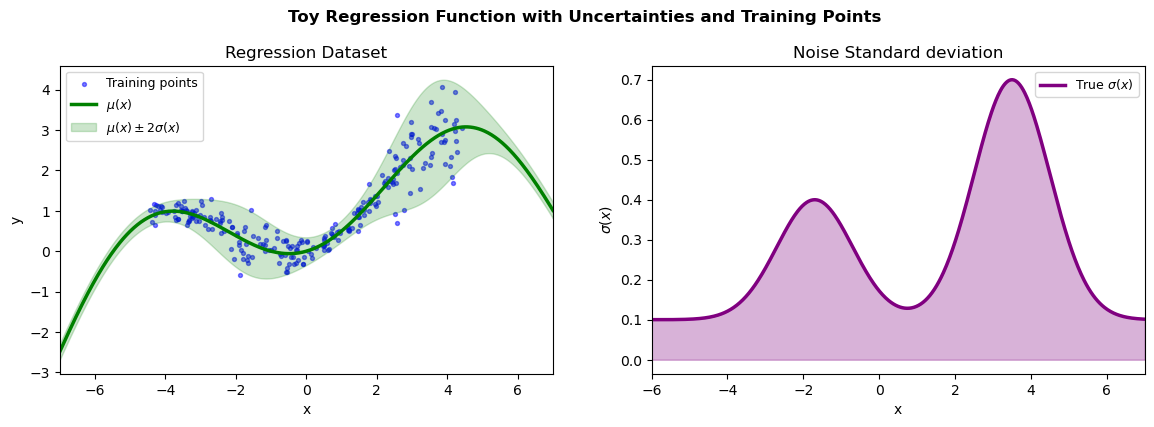

In [105]:
# ─── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.scatter(x_tr, y_tr, s=8, alpha=0.5, color="blue", label="Training points")
ax.plot(x_te, true_mean(x_te), color="green", lw=2.5, label=r"$\mu(x)$")
ax.fill_between(x_te,
                true_mean(x_te) - 2*true_std(x_te),
                true_mean(x_te) + 2*true_std(x_te),
                alpha=0.2, color="green", label=r"$\mu(x)\pm2\sigma(x)$")
ax.set(xlabel="x", ylabel="y", title="Regression Dataset", xlim=(-7, 7))
ax.legend(fontsize=9)

ax = axes[1]
ax.fill_between(x_te, 0, true_std(x_te), alpha=0.3, color="purple")
ax.plot(x_te, true_std(x_te), color="purple", lw=2.5, label=r"True $\sigma(x)$")
ax.set(xlabel="x", ylabel=r"$\sigma(x)$",
       title="Noise Standard deviation", xlim=(-6, 7))
ax.legend(fontsize=9)

plt.suptitle("Toy Regression Function with Uncertainties and Training Points",
             fontsize=12, y=1.02, fontweight="bold");

---
## 2 Model Training Setup

Prepare training data and generic training loop 

In [106]:
x_tr_t = torch.from_numpy(x_tr).unsqueeze(1).to(device)
y_tr_t = torch.from_numpy(y_tr).unsqueeze(1).to(device)
x_te_t = torch.from_numpy(x_te).unsqueeze(1).to(device)

# ─── Generic training loop ────────────────────────────────────────────────────
def fit(model, loss_fn, n_epochs=1000, lr=1e-4, bs=32, verbose=True):
    opt  = optim.Adam(model.parameters(), lr=lr)
    dl   = DataLoader(TensorDataset(x_tr_t, y_tr_t), batch_size=bs, shuffle=True)
    hist = []
    ep_loss = 0.

    for ep in range(n_epochs):
        model.train()
        print(f"Iter [{ep+1}/{n_epochs}] - Loss {ep_loss:.5f} ...  ", end="\r")
        ep_loss = 0.

        for xb, yb in dl:
            opt.zero_grad()
            l = loss_fn(model, xb, yb)
            l.backward(); 
            opt.step()
            ep_loss += l.item()

        hist.append(ep_loss / len(dl))
    if verbose:
        print(f"Final loss: {hist[-1]:.4f}")
    return hist

---
## 2.1  Deterministic MLP — No Uncertainty

A standard MLP with one output $$f_\theta(x)=\hat y$$
and trained with Mean Squared Error (**MSE**) loss $$\mathcal{L}(x,\hat y) = (x-\hat y)^2~.$$

This model gives only a *point prediction*, no uncertainty. 

#### Model and Loss Implementation

In [107]:
# ─── Architecture helper ──────────────────────────────────────────────────────
def make_mlp(out_dim=1, hidden=64, n_layers=2, dropout=0.1): #128, 5
    act = nn.GELU
    layers = [nn.Linear(1, hidden), act()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(hidden, hidden), act()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    layers.append(nn.Linear(hidden, out_dim))
    return nn.Sequential(*layers)

def mse_loss(model, xb, yb):
    return nn.functional.mse_loss(model(xb), yb)

#### Model Training

In [108]:
# ─── Create Model and Train ───────────────────────────────────────────────────
det_mlp = make_mlp().to(device)
fit(det_mlp, mse_loss, n_epochs=1000);



Final loss: 0.1424 Loss 1.12241 ...  


#### Model Evaluation

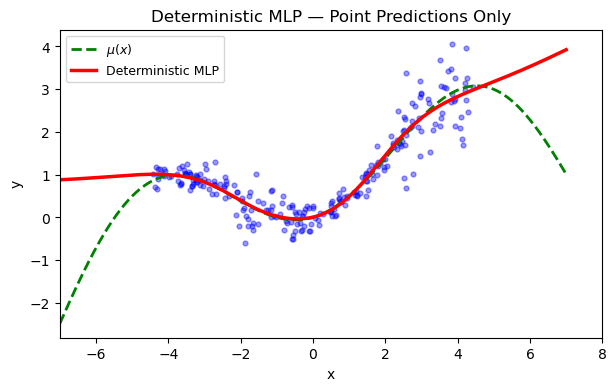

In [109]:
# ─── Predict & Plot ───────────────────────────────────────────────────────────
det_mlp.eval()
with torch.no_grad():
    y_det = det_mlp(x_te_t).cpu().squeeze().numpy()

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.scatter(x_tr, y_tr, s=12, alpha=0.4, color="blue", zorder=-1)
ax.plot(x_te, true_mean(x_te), color="green", lw=2, ls="--", label=r"$\mu(x)$")
ax.plot(x_te, y_det, color="red", lw=2.5, label="Deterministic MLP")
ax.set(xlabel="x", ylabel="y", title="Deterministic MLP — Point Predictions Only",
       xlim=(-7, 8))
ax.legend(fontsize=9);


---
## 2.2  Probabilistic Regression with Gaussian negative log-likelihood loss (NLL)

Instead of predicting a single number we predict a **full Gaussian**:

$$
f_\theta(x) \rightarrow \bigl(\mu_\theta(x),\; \log\sigma^2_\theta(x)\bigr)
$$

Training loss = **Negative Log-Likelihood** under Gaussian:

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^N \left[\frac{(y_i - \mu_i)^2}{2\sigma_i^2}
                 + \frac{1}{2}\log\sigma_i^2\right]$$

The model now ***learns*** **the data noise**.

This captures **aleatoric** uncertainty only.

#### Model and Loss Implementation

In [110]:
# ─── Gaussian NLL Model ───────────────────────────────────────────────────────
class GaussianMLP(nn.Module):
    def __init__(self, hidden=64, n_layers=2, dropout=0.1): # 128, 5
        super().__init__()
        act = nn.GELU
        layers = [nn.Linear(1, hidden), act()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), act()]
            if dropout > 0: layers.append(nn.Dropout(dropout))
        self.backbone = nn.Sequential(*layers)
        self.mu_head  = nn.Linear(hidden, 1)
        self.lv_head  = nn.Linear(hidden, 1)  # log-variance

    def forward(self, x):
        h = self.backbone(x)
        return self.mu_head(h), torch.clamp(self.lv_head(h), -10, 4)

def gauss_nll(model, xb, yb):
    mu, lv = model(xb)
    return 0.5 * (lv + (yb - mu).pow(2) / lv.exp()).mean()

#### Model Training

In [ ]:
model_gauss = GaussianMLP().to(device)
fit(model_gauss, gauss_nll, n_epochs=1000);


Final loss: -0.7079Loss -6.21406 ...  


[0.9867705479264259,
 0.8928035423159599,
 0.8191546276211739,
 0.7395075038075447,
 0.6842447631061077,
 0.6224064081907272,
 0.5791872553527355,
 0.5267841592431068,
 0.4747116081416607,
 0.428860567510128,
 0.39204241335392,
 0.36039454117417336,
 0.3042922466993332,
 0.2670666519552469,
 0.23346800170838833,
 0.18974921200424433,
 0.157715599052608,
 0.1194146741181612,
 0.07872544368728995,
 0.04118727007880807,
 0.0016844883793964982,
 -0.038132454705191776,
 -0.0700529576279223,
 -0.09917867835611105,
 -0.1313150990754366,
 -0.15151628060266376,
 -0.1759899640455842,
 -0.18759234435856342,
 -0.21963176596909761,
 -0.24974657222628593,
 -0.2483024075627327,
 -0.25558694917708635,
 -0.25777301099151373,
 -0.2657318445853889,
 -0.29010739363729954,
 -0.3106256928294897,
 -0.32949429377913475,
 -0.29190134536474943,
 -0.3080313573591411,
 -0.34797264263033867,
 -0.32958661392331123,
 -0.3722657971084118,
 -0.32631930336356163,
 -0.3634479781612754,
 -0.3650174140930176,
 -0.34588476

#### Model Evaluation

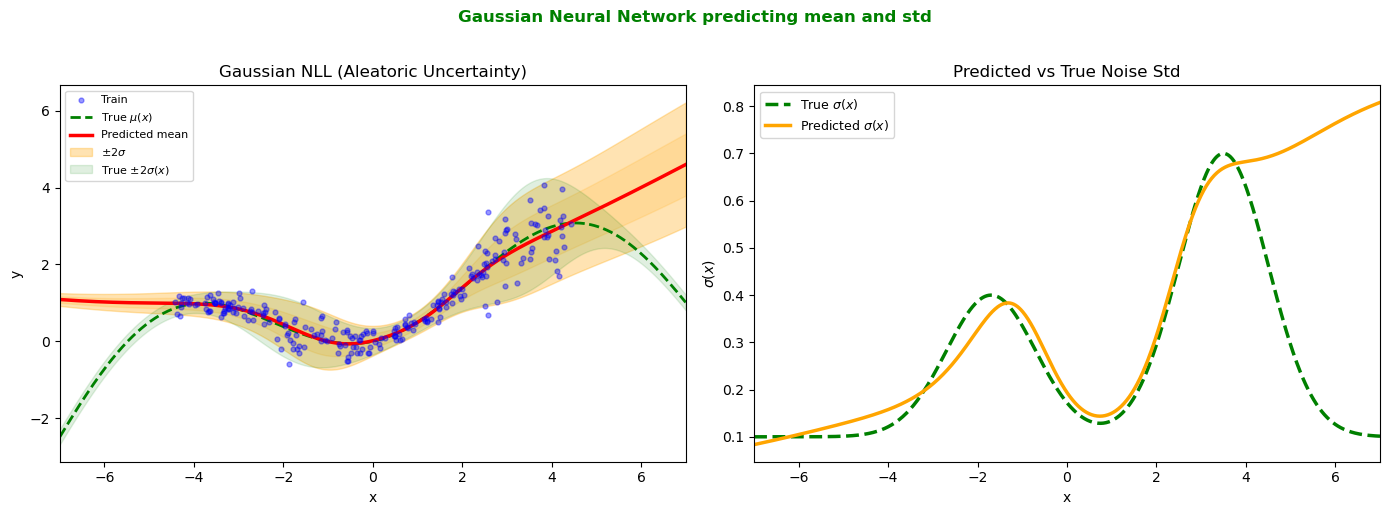

In [112]:
model_gauss.eval()
with torch.no_grad():
    mu_g, lv_g = model_gauss(x_te_t)
    mu_g    = mu_g.cpu().squeeze().numpy()
    sigma_g = lv_g.mul(.5).exp().cpu().squeeze().numpy()

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(x_tr, y_tr, s=12, alpha=0.4, color="blue", zorder=4, label="Train")
ax.plot(x_te, true_mean(x_te), color="green", lw=2, ls="--", label=r"True $\mu(x)$")
ax.plot(x_te, mu_g, color="red", lw=2.5, label="Predicted mean")
for n, a, lbl in [(2, .3, r"$\pm 2\sigma$"), (1, .15, r"$Predicted \pm 2\sigma(x)$")]:
    ax.fill_between(x_te, mu_g - n*sigma_g, mu_g + n*sigma_g,
                    alpha=a, color="orange", label=lbl if n==2 else None)
ax.fill_between(x_te,
                true_mean(x_te) - 2*true_std(x_te),
                true_mean(x_te) + 2*true_std(x_te),
                alpha=0.12, color="green", label=r"True $\pm 2\sigma(x)$")
ax.set(xlabel="x", ylabel="y", title="Gaussian NLL (Aleatoric Uncertainty)", xlim=(-7, 7))
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x_te, true_std(x_te), color="green", lw=2.5, ls="--", label=r"True $\sigma(x)$")
ax.plot(x_te, sigma_g, color="orange", lw=2.5, label=r"Predicted $\sigma(x)$")
ax.set(xlabel="x", ylabel=r"$\sigma(x)$",
       title="Predicted vs True Noise Std", xlim=(-7, 7))
ax.legend(fontsize=9)

plt.suptitle("Gaussian Neural Network predicting mean and std",
             color="green", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 2.3  Quantile Regression — No Distributional Assumption!

Instead of a Gaussian head, we predict **quantiles** directly.

**Pinball loss** for quantile $q \in (0,1)$:

$$\rho_q(u) = u\,(q - \mathbf{1}_{u<0}) =
  \begin{cases} q\,u & u \geq 0 \\ (q-1)\,u & u < 0 \end{cases}$$

We train one model that outputs **multiple quantiles simultaneously**,
e.g. `[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]`.

> ✅ **No Gaussian assumption** — works with any noise distribution!


#### Model and Loss Implemantation

In [113]:
QUANTS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
N_Q    = len(QUANTS)

class QReg(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, N_Q))
    def forward(self, x): return self.net(x)

def pinball(model, xb, yb):
    q_pred = model(xb)                          # [B, N_Q]
    yb_exp = yb.expand_as(q_pred)               # [B, N_Q]
    q_t    = torch.tensor(QUANTS, device=xb.device, dtype=xb.dtype)
    u      = yb_exp - q_pred
    loss   = torch.max((q_t - 1) * u, q_t * u)
    return loss.mean()


#### Model Training

In [114]:
model_qreg = QReg().to(device)
fit(model_qreg, pinball, n_epochs=2000);

Final loss: 0.0701 Loss 0.55319 ...  


#### Model Evaluation

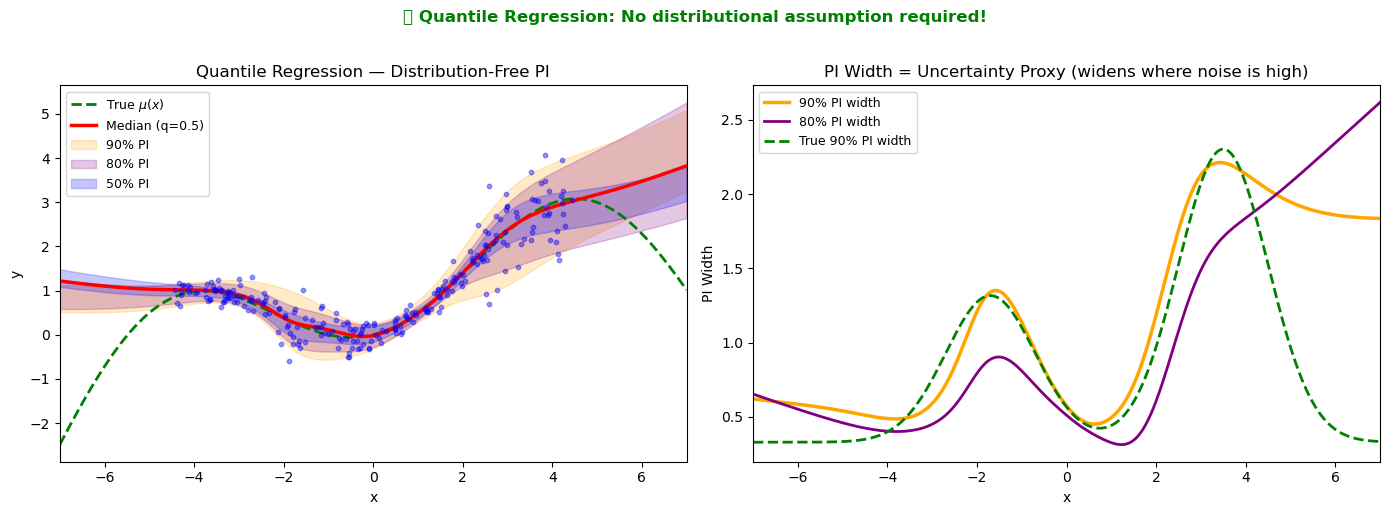

In [115]:
model_qreg.eval()
with torch.no_grad():
    q_preds = model_qreg(x_te_t).cpu().numpy()  # [500, 7]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(x_tr, y_tr, s=10, alpha=0.4, color="blue", zorder=4)
ax.plot(x_te, true_mean(x_te), color="green", lw=2, ls="--", label=r"True $\mu(x)$")
ax.plot(x_te, q_preds[:,3], color="red", lw=2.5, label="Median (q=0.5)")
bands = [((0,6), "ORANGE", "90% PI"), ((1,5), "PURPLE", "80% PI"), ((2,4), "BLUE", "50% PI")]
for (lo,hi), col, lbl in bands:
    ax.fill_between(x_te, q_preds[:,lo], q_preds[:,hi], alpha=0.22, color=col, label=lbl)
ax.set(xlabel="x", ylabel="y", title="Quantile Regression — Distribution-Free PI", xlim=(-7, 7))
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(x_te, q_preds[:,6]-q_preds[:,0], color="orange", lw=2.5, label="90% PI width")
ax.plot(x_te, q_preds[:,5]-q_preds[:,1], color="purple", lw=2, label="80% PI width")
ax.plot(x_te, 2*1.645*true_std(x_te), color="green", lw=2, ls="--", label="True 90% PI width")
ax.set(xlabel="x", ylabel="PI Width",
       title="PI Width = Uncertainty Proxy (widens where noise is high)", xlim=(-7, 7))
ax.legend(fontsize=9)

plt.suptitle("✅ Quantile Regression: No distributional assumption required!",
             color="green", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 2.4  Epistemic Uncertainty — MC Dropout

**Dropout** randomly zeroes activations during training.

**Key adjustment**: keep dropout **active at test time** and run T forward passes:

$$\hat{\mu}(x) = \frac{1}{T}\sum_t \mu_t(x) \qquad
  \underbrace{\hat{\sigma}^2_{\text{epist}}(x)}_\text{epistemic}
  = \text{Var}_t[\mu_t(x)] \qquad
  \underbrace{\hat{\sigma}^2_{\text{aleat}}(x)}_\text{aleatoric}
  = \frac{1}{T}\sum_t \sigma_t^2(x)$$

> `model.train()` must be called at inference to keep dropout active, but be careful with BatchNorm etc.!


#### Model, Prediction, and Loss Implementation
No architectural change compared to Gaussian MLP needed

In [116]:
# ─── MC Inference ─────────────────────────────────────────────────────────────
def mc_predict(model, x_t, T=200):
    # ─── Keep the model in training mode in order to activate DropOut
    model.train() 
    # ─────────────────────────────────────────────────────────────
    mus, sigmas = [], []
    with torch.no_grad():
        for _ in range(T):
            mu, lv = model(x_t)
            mus.append(mu.cpu().squeeze().numpy())
            sigmas.append(lv.mul(.5).exp().cpu().squeeze().numpy())
    mus    = np.stack(mus)     # [T, N]
    sigmas = np.stack(sigmas)
    mu_hat      = mus.mean(0)
    var_epi     = mus.var(0)
    var_ale     = (sigmas**2).mean(0)
    var_tot     = var_epi + var_ale
    return mu_hat, np.sqrt(var_epi), np.sqrt(var_ale), np.sqrt(var_tot), mus

#### Model Training

In [117]:
mc_model = GaussianMLP(hidden=64, n_layers=2, dropout=0.3).to(device)
fit(mc_model, gauss_nll, n_epochs=1000);

Final loss: -0.6967Loss -5.34694 ...  


#### Model Evaluation

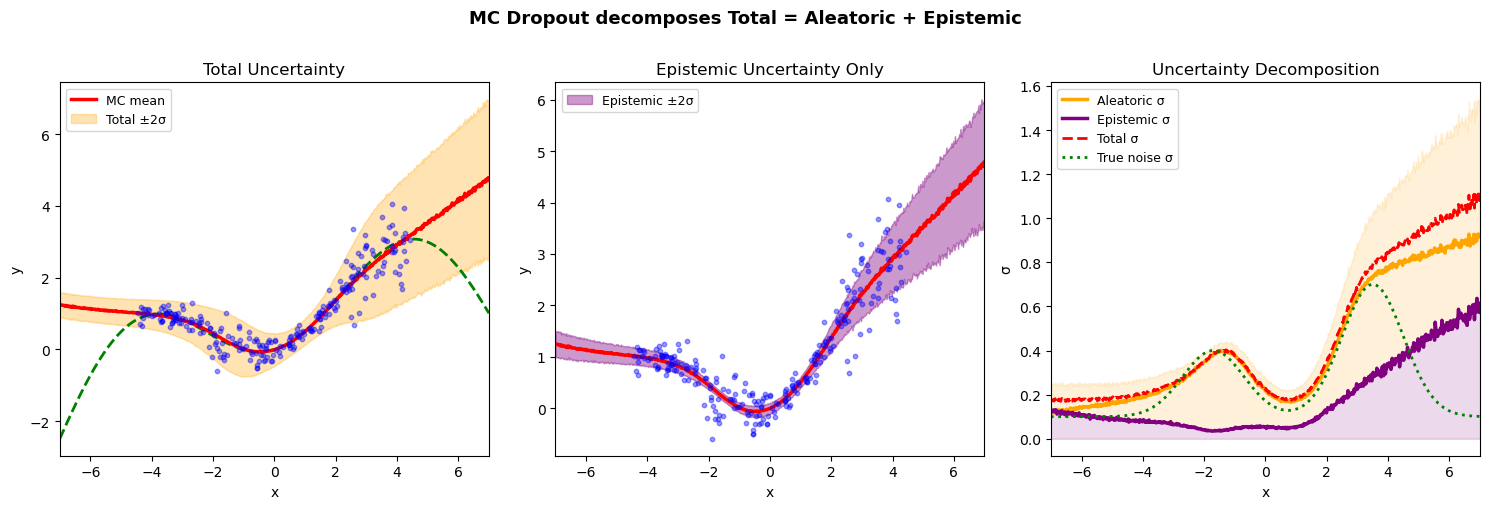

In [ ]:

mu_mc, sig_ep, sig_al, sig_tot, mc_samples = mc_predict(mc_model, x_te_t, T=300)

# ─── 4-panel uncertainty decomposition ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.scatter(x_tr, y_tr, s=10, alpha=0.4, color="BLUE", zorder=4)
ax.plot(x_te, true_mean(x_te), color="green", lw=2, ls="--")
ax.plot(x_te, mu_mc, color="red", lw=2.5, label="MC mean")
ax.fill_between(x_te, mu_mc - 2*sig_tot, mu_mc + 2*sig_tot,
                alpha=0.3, color="orange", label="Total ±2σ")
ax.set(xlabel="x", ylabel="y", title="Total Uncertainty", xlim=(-7, 7))
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(x_tr, y_tr, s=10, alpha=0.4, color="blue", zorder=4)
ax.plot(x_te, mu_mc, color="red", lw=2.5)
ax.fill_between(x_te, mu_mc - 2*sig_ep, mu_mc + 2*sig_ep,
                alpha=0.4, color="purple", label="Epistemic ±2σ")
ax.set(xlabel="x", ylabel="y", title="Epistemic Uncertainty Only", xlim=(-7, 7))
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(x_te, sig_al,  color="orange", lw=2.5, label="Aleatoric σ")
ax.plot(x_te, sig_ep,  color="purple", lw=2.5, label="Epistemic σ")
ax.plot(x_te, sig_tot, color="red",    lw=2.0, ls="--", label="Total σ")
ax.plot(x_te, true_std(x_te), color="green", lw=2, ls=":", label="True noise σ")
ax.set(xlabel="x", ylabel="σ", title="Uncertainty Decomposition", xlim=(-7, 7))
ax.legend(fontsize=9)

plt.suptitle("MC Dropout decomposes Total = Aleatoric + Epistemic",
             fontsize=13, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 2.5  Deep Ensembles

Train $M$ **independently initialised** models.  The prediction is the mean:

$$
p(y|x) \approx \frac{1}{M}\sum_{m=1}^M \mathcal{N}(y;\mu_m,\sigma_m^2)
$$

**Variance decomposition** (law of total variance):

$$\underbrace{\sigma^2_{\text{total}}}_{\text{total}}
  = \underbrace{\frac{1}{M}\sum_m\sigma_m^2}_{\text{aleatoric}}
  + \underbrace{\frac{1}{M}\sum_m(\mu_m-\bar\mu)^2}_{\text{epistemic}}$$

> **Pros**: simple, reliable, state-of-the-art performance  
> **Cons**: $M\times$ training / inference cost


#### Model, Loss, Evalution Implementation

In [119]:
num_members = 5

def ens_predict(models, x_t):
    mus, sigs = [], []
    for mdl in models:
        mdl.eval()
        with torch.no_grad():
            mu, lv = mdl(x_t)
            mus.append(mu.cpu().squeeze().numpy())
            sigs.append(lv.mul(.5).exp().cpu().squeeze().numpy())
    mus  = np.stack(mus)
    sigs = np.stack(sigs)
    mu_e    = mus.mean(0)
    var_al  = (sigs**2).mean(0)
    var_ep  = mus.var(0)
    return mu_e, np.sqrt(var_al), np.sqrt(var_ep), np.sqrt(var_al+var_ep), mus

#### Model Training

In [120]:
ensemble = []
print(f"Training {num_members} ensemble members …")
for i in range(num_members):
    torch.manual_seed(i * 777)
    m = GaussianMLP(hidden=32, n_layers=2).to(device) # 128, 5
    fit(m, gauss_nll, n_epochs=1000, verbose=False);
    ensemble.append(m)
    print(f"  [{i+1}/{num_members}] done")

Training 5 ensemble members …
  [1/5] done000] - Loss -5.64597 ...  
  [2/5] done000] - Loss -5.73252 ...  
  [3/5] done000] - Loss -5.53188 ...  
  [4/5] done000] - Loss -5.90862 ...  
  [5/5] done000] - Loss -5.35237 ...  


#### Model Evaluation

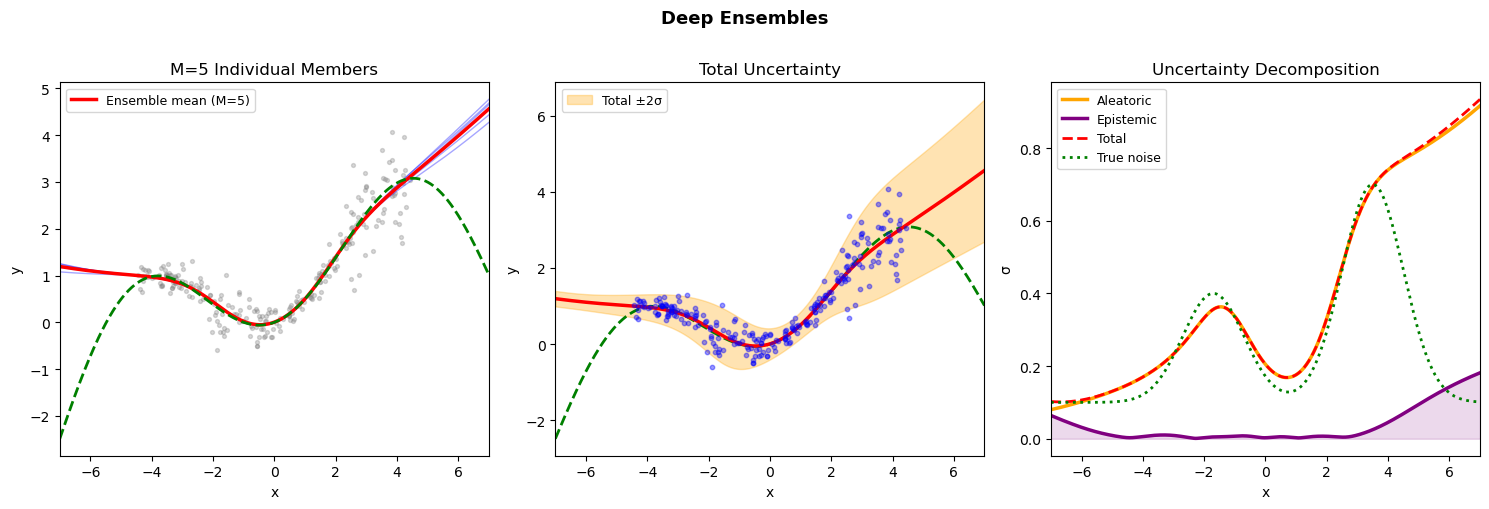

In [ ]:

mu_ens, sal_ens, sep_ens, stot_ens, all_mus = ens_predict(ensemble, x_te_t)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
for m_pred in all_mus:
    ax.plot(x_te, m_pred, alpha=0.35, lw=1, color="blue")
ax.plot(x_te, mu_ens, color="red", lw=2.5, label=f"Ensemble mean (M={num_members})")
ax.plot(x_te, true_mean(x_te), color="green", lw=2, ls="--")
ax.scatter(x_tr, y_tr, s=8, alpha=0.3, color="gray")
ax.set(title=f"M={num_members} Individual Members", xlabel="x", ylabel="y", xlim=(-7, 7))
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(x_tr, y_tr, s=10, alpha=0.4, color="blue", zorder=4)
ax.plot(x_te, true_mean(x_te), color="green", lw=2, ls="--")
ax.plot(x_te, mu_ens, color="red", lw=2.5)
ax.fill_between(x_te, mu_ens-2*stot_ens, mu_ens+2*stot_ens,
                alpha=0.3, color="orange", label="Total ±2σ")
ax.set(title="Total Uncertainty", xlabel="x", ylabel="y", xlim=(-7, 7))
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(x_te, sal_ens, color="orange", lw=2.5, label="Aleatoric")
ax.plot(x_te, sep_ens, color="purple", lw=2.5, label="Epistemic")
ax.plot(x_te, stot_ens, color="red", lw=2, ls="--", label="Total")
ax.plot(x_te, true_std(x_te), color="green", lw=2, ls=":", label="True noise")
ax.set(title="Uncertainty Decomposition", xlabel="x", ylabel="σ", xlim=(-7, 7))
ax.legend(fontsize=9)


plt.suptitle("Deep Ensembles",
             fontsize=13, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 8  Spectral-Normalized Gaussian Process (SNGP)

Standard NNs can be confidently wrong **far from training data**.

SNGP fixes this by:

1. **Spectral normalization** on all weight matrices
   → preserves distances: similar inputs stay similar in feature space

2. **Gaussian Process output layer** via Random Fourier Features
   → uncertainty grows with distance from training data

$$
\Phi(x) = \sqrt{\tfrac{2}{D}}\cos\!\left(W_{\text{rff}}\,h(x) + b\right)
$$
$$
f(x) = \beta^T\Phi(x), \quad \beta \sim \mathcal{N}(0,\Sigma_{\text{posterior}})
$$

The GP posterior gives **distance-aware** uncertainty.


#### Model, Loss and Evalution Implementation

In [122]:
from torch.nn.utils import spectral_norm as SN

class SNGP(nn.Module):
    """Simplified SNGP for regression."""
    def __init__(self, hidden=64, n_layers=2, D=1024, ridge=1e-2):
        super().__init__()
        layers, h = [], 1
        for _ in range(n_layers):
            fc = SN(nn.Linear(h, hidden))
            layers += [fc, nn.GELU()]
            h = hidden
        self.backbone = nn.Sequential(*layers)
        # Fixed random Fourier features
        self.register_buffer("W_rff", torch.randn(hidden, D))
        self.register_buffer("b_rff", torch.rand(D) * 2 * np.pi)
        self.output = nn.Linear(D, 1, bias=False)
        # Precision matrix (Laplace approx.)
        self.register_buffer("prec", torch.eye(D) * ridge)
        self.ridge = ridge
        self.D = D

    def phi(self, x):
        h = self.backbone(x)
        return (2./self.D)**.5 * torch.cos(h @ self.W_rff + self.b_rff)

    def forward(self, x, return_var=False):
        p = self.phi(x)
        mean = self.output(p)
        if return_var:
            # posterior variance φ Σ φ^T (diagonal of the outer product)
            prec_inv = torch.linalg.inv(self.prec)
            var = (p @ prec_inv * p).sum(-1, keepdim=True)
            return mean, var
        return mean

    def update_prec(self, loader):
        """One pass to build the Laplace precision matrix."""
        self.prec.data = torch.eye(self.D, device=self.prec.device) * self.ridge
        self.eval()
        with torch.no_grad():
            for xb, _ in loader:
                p = self.phi(xb.to(self.prec.device))
                self.prec.data += p.T @ p

In [123]:
model_sngp = SNGP(hidden=64, n_layers=2, D=512).to(device)

opt_sn = optim.Adam([p for n,p in model_sngp.named_parameters()
                     if p.requires_grad and "prec" not in n], lr=3e-4)
dl_sn  = DataLoader(TensorDataset(x_tr_t, y_tr_t), batch_size=64, shuffle=True)

print("Training SNGP …")
for ep in range(2500):
    model_sngp.train()
    for xb, yb in dl_sn:
        opt_sn.zero_grad()
        nn.MSELoss()(model_sngp(xb), yb).backward()
        opt_sn.step()

model_sngp.update_prec(dl_sn)   # fit GP posterior after training
print("Training Done")

Training SNGP …
Training Done


#### Model Evaluation

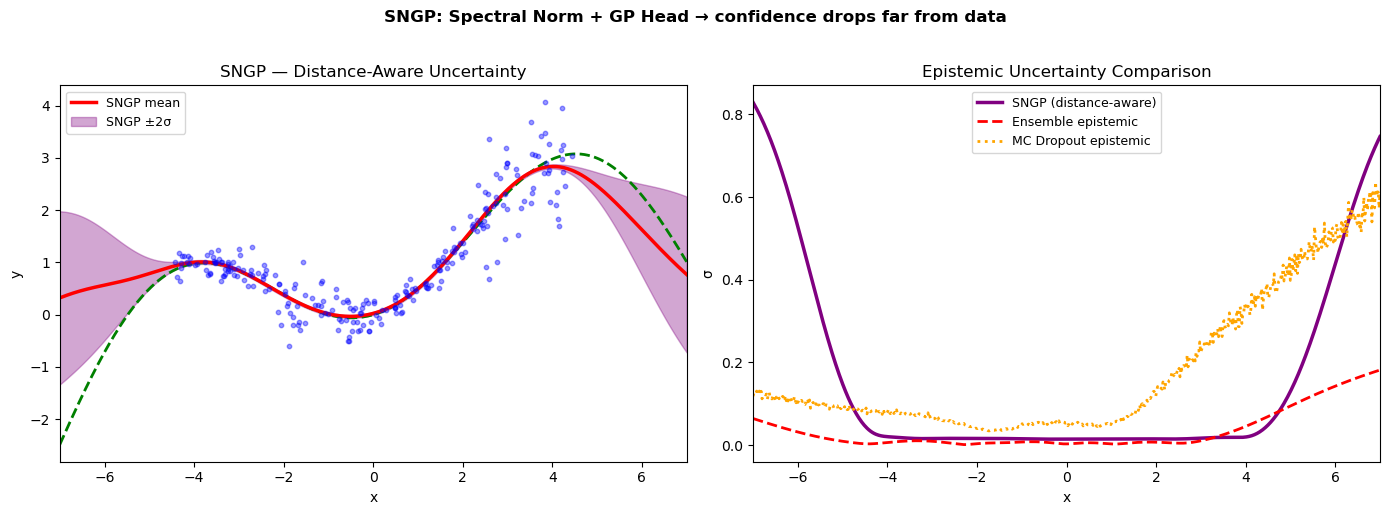

In [124]:
model_sngp.eval()
with torch.no_grad():
    mu_sn, var_sn = model_sngp(x_te_t, return_var=True)
    mu_sn  = mu_sn.cpu().squeeze().numpy()
    std_sn = var_sn.sqrt().cpu().squeeze().numpy()
    # Normalise to interpretable scale
    std_sn = std_sn / (std_sn[(np.abs(x_te) > 4.5)].mean() + 1e-8) * .4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(x_tr, y_tr, s=10, alpha=0.4, color="blue", zorder=4)
ax.plot(x_te, true_mean(x_te), color="green", lw=2, ls="--")
ax.plot(x_te, mu_sn, color="red", lw=2.5, label="SNGP mean")
ax.fill_between(x_te, mu_sn-2*std_sn, mu_sn+2*std_sn,
                alpha=0.35, color="purple", label="SNGP ±2σ")
ax.set(title="SNGP — Distance-Aware Uncertainty", xlabel="x", ylabel="y", xlim=(-7, 7))
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(x_te, std_sn,   color="purple", lw=2.5, label="SNGP (distance-aware)")
ax.plot(x_te, sep_ens,  color="red",    lw=2, ls="--", label=f"Ensemble epistemic")
ax.plot(x_te, sig_ep,   color="orange", lw=2, ls=":",  label="MC Dropout epistemic")
ax.set(title="Epistemic Uncertainty Comparison", xlabel="x", ylabel="σ", xlim=(-7, 7))
ax.legend(fontsize=9)

plt.suptitle("SNGP: Spectral Norm + GP Head → confidence drops far from data",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 3  Summary: All Methods Side by Side



┌───────────────────────────────────────────────────────┐
│           Regression UQ — Summary Table               │
├──────────────────┬──────────┬───────────┬─────────────┤
│  Method          │ Aleat.   │ Epist.    │ Cost        │
├──────────────────┼──────────┼───────────┼─────────────┤
│  Plain MLP       │   ❌     │   ❌      │ Low         │
│  Gaussian NLL    │   ✅     │   ❌      │ Low         │
│  MC Dropout      │   ✅     │   ✅      │ Low         │
│  Deep Ensemble   │   ✅     │   ✅      │ High        │
│  Quantile Reg    │   ✅     │   ❌      │ Medium      │
└──────────────────┴──────────┴───────────┴─────────────┘



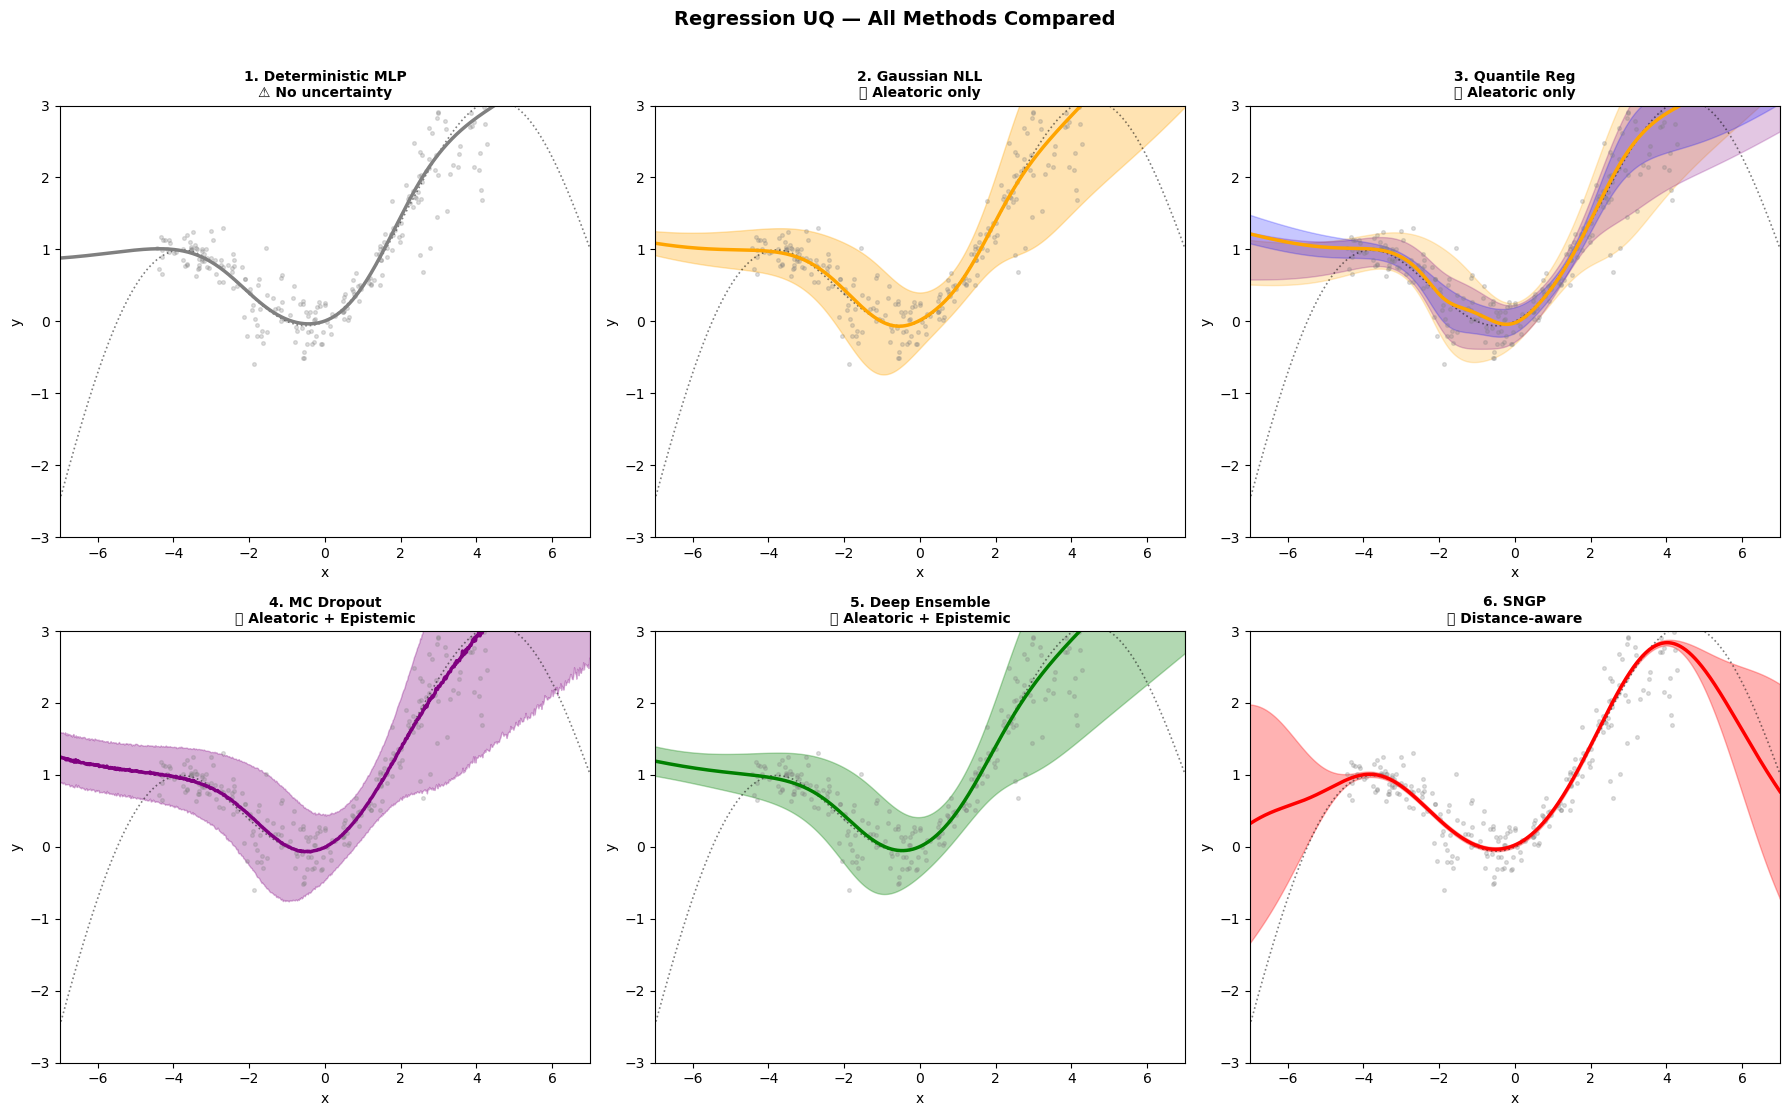

In [ ]:
print("""
┌───────────────────────────────────────────────────────┐
│           Regression UQ — Summary Table               │
├──────────────────┬──────────┬───────────┬─────────────┤
│  Method          │ Aleat.   │ Epist.    │ Cost        │
├──────────────────┼──────────┼───────────┼─────────────┤
│  Plain MLP       │   ❌     │   ❌      │ Low         │
│  Gaussian NLL    │   ✅     │   ❌      │ Low         │
│  Quantile Reg    │   ✅     │   ❌      │ Medium      │
│  MC Dropout      │   ✅     │   ✅      │ Low         │
│  Deep Ensemble   │   ✅     │   ✅      │ High        │
└──────────────────┴──────────┴───────────┴─────────────┘
""")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

methods = [
    ("1. Deterministic MLP",  x_te, y_det,   np.zeros_like(x_te), "GRAY",   "⚠ No uncertainty"),
    ("2. Gaussian NLL",       x_te, mu_g,    sigma_g,             "ORANGE", "✅ Aleatoric only"),
    ("3. Quantile Reg",       x_te, q_preds[:,3],    q_preds[:,1],             "ORANGE", "✅ Aleatoric only"),    
    ("4. MC Dropout",         x_te, mu_mc,   sig_tot,             "PURPLE", "✅ Aleatoric + Epistemic"),
    ("5. Deep Ensemble",      x_te, mu_ens,  stot_ens,            "GREEN",  "✅ Aleatoric + Epistemic"),
    ("6. SNGP",               x_te, mu_sn,   std_sn,              "RED",    "✅ Distance-aware"),
]
for ax, (name, x, mu, sigma, color, tag) in zip(axes, methods):
    ax.scatter(x_tr, y_tr, s=7, alpha=0.25, color="GRAY", zorder=2)
    ax.plot(x_te, true_mean(x_te), "k:", lw=1.2, alpha=0.5)
    ax.plot(x, mu, color=color, lw=2.5, label="Prediction")
    if name != "3. Quantile Reg":
        if sigma.max() > 1e-5:
            ax.fill_between(x, mu-2*sigma, mu+2*sigma, alpha=0.3, color=color, label="±2σ")
    else:
        bands = [((0,6), "ORANGE", "90% PI"), ((1,5), "PURPLE", "80% PI"), ((2,4), "BLUE", "50% PI")]
        for (lo,hi), col, lbl in bands:
            ax.fill_between(x_te, q_preds[:,lo], q_preds[:,hi], alpha=0.22, color=col, label=lbl)
        
    ax.set_title(f"{name}\n{tag}", fontsize=10, fontweight="bold")
    ax.set(xlim=(-7, 7), ylim=(-3,3), xlabel="x", ylabel="y")

plt.suptitle("Regression UQ — All Methods Compared",
             fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()